In [5]:
!apt-get update

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,309 kB]
Get:14 https://

In [6]:
!apt-get -y install mysql-server

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libaio1 libcgi-fast-perl libcgi-pm-perl libclone-perl libencode-locale-perl
  libfcgi-bin libfcgi-perl libfcgi0ldbl libhtml-parser-perl
  libhtml-tagset-perl libhtml-template-perl libhttp-date-perl
  libhttp-message-perl libio-html-perl liblwp-mediatypes-perl libmecab2
  libprotobuf-lite23 liburi-perl mecab-ipadic mecab-ipadic-utf8 mecab-utils
  mysql-client-8.0 mysql-client-core-8.0 mysql-server-8.0
  mysql-server-core-8.0
Suggested packages:
  libdata-dump-perl libipc-sharedcache-perl libbusiness-isbn-perl libwww-perl
  mailx tinyca
The following NEW packages will be installed:
  libaio1 libcgi-fast-perl libcgi-pm-perl libclone-perl libencode-locale-perl
  libfcgi-bin libfcgi-perl libfcgi0ldbl libhtml-parser-perl
  libhtml-tagset-perl libhtml-template-perl libhttp-date-perl
  libhttp-message-perl libio-html-perl liblwp-mediatypes-perl

In [7]:
!service mysql status

 * MySQL is stopped.


In [8]:
!service mysql start

 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.


In [9]:
!service mysql status

 * /usr/bin/mysqladmin  Ver 8.0.46-0ubuntu0.22.04.3 for Linux on x86_64 ((Ubuntu))
Copyright (c) 2000, 2026, Oracle and/or its affiliates.

Oracle is a registered trademark of Oracle Corporation and/or its
affiliates. Other names may be trademarks of their respective
owners.

Server version		8.0.46-0ubuntu0.22.04.3
Protocol version	10
Connection		Localhost via UNIX socket
UNIX socket		/var/run/mysqld/mysqld.sock
Uptime:			5 min 34 sec

Threads: 2  Questions: 8  Slow queries: 0  Opens: 119  Flush tables: 3  Open tables: 38  Queries per second avg: 0.023


In [10]:
!mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'colabpass123'; FLUSH PRIVILEGES;"

In [11]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="colabpass123"
)

print(conn.is_connected())

True


In [12]:
cursor = conn.cursor()
cursor.execute("CREATE DATABASE IF NOT EXISTS sales_db")
print("Database ready")

Database ready


In [13]:
cursor.execute("USE sales_db")

In [14]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INT AUTO_INCREMENT PRIMARY KEY,
    product VARCHAR(50) NOT NULL,
    quantity INT NOT NULL,
    price DECIMAL(10,2) NOT NULL,
    sale_date DATE NOT NULL
)
""")
print("Table created")

Table created


In [15]:
cursor.execute("SHOW TABLES")
print(cursor.fetchall())

[('sales',)]


In [16]:
cursor.execute("""
    INSERT INTO sales (product, quantity, price, sale_date)
    VALUES (%s, %s, %s, %s)
""", ("Widget", 10, 5.00, "2026-06-01"))
conn.commit()

In [17]:
data = [
    ("Gadget", 5, 12.50, "2026-06-01"),
    ("Gadget", 8, 12.50, "2026-06-05"),
    ("Gizmo", 3, 20.00, "2026-06-02"),
]
cursor.executemany("""
    INSERT INTO sales (product, quantity, price, sale_date)
    VALUES (%s, %s, %s, %s)
""", data)
conn.commit()

In [18]:
cursor.execute("SELECT * FROM sales")
for row in cursor.fetchall():
    print(row)

(1, 'Widget', 10, Decimal('5.00'), datetime.date(2026, 6, 1))
(2, 'Gadget', 5, Decimal('12.50'), datetime.date(2026, 6, 1))
(3, 'Gadget', 8, Decimal('12.50'), datetime.date(2026, 6, 5))
(4, 'Gizmo', 3, Decimal('20.00'), datetime.date(2026, 6, 2))


In [19]:
data = [
    ("Widget", 7, 5.00, "2026-06-03"),
    ("Widget", 4, 5.00, "2026-06-07"),
    ("Gizmo", 6, 20.00, "2026-06-06"),
    ("Doohickey", 12, 8.00, "2026-06-04"),
    ("Doohickey", 9, 8.00, "2026-06-08"),
    ("Gadget", 2, 12.50, "2026-06-09"),
]
cursor.executemany("""
    INSERT INTO sales (product, quantity, price, sale_date)
    VALUES (%s, %s, %s, %s)
""", data)
conn.commit()
print(f"Inserted {cursor.rowcount} rows")

Inserted 6 rows


In [20]:
cursor.execute("SELECT * FROM sales")
for row in cursor.fetchall():
    print(row)

(1, 'Widget', 10, Decimal('5.00'), datetime.date(2026, 6, 1))
(2, 'Gadget', 5, Decimal('12.50'), datetime.date(2026, 6, 1))
(3, 'Gadget', 8, Decimal('12.50'), datetime.date(2026, 6, 5))
(4, 'Gizmo', 3, Decimal('20.00'), datetime.date(2026, 6, 2))
(5, 'Widget', 7, Decimal('5.00'), datetime.date(2026, 6, 3))
(6, 'Widget', 4, Decimal('5.00'), datetime.date(2026, 6, 7))
(7, 'Gizmo', 6, Decimal('20.00'), datetime.date(2026, 6, 6))
(8, 'Doohickey', 12, Decimal('8.00'), datetime.date(2026, 6, 4))
(9, 'Doohickey', 9, Decimal('8.00'), datetime.date(2026, 6, 8))
(10, 'Gadget', 2, Decimal('12.50'), datetime.date(2026, 6, 9))


In [21]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC
"""

cursor.execute(query)
for row in cursor.fetchall():
    print(row)

('Gadget', Decimal('15'), Decimal('187.50'))
('Gizmo', Decimal('9'), Decimal('180.00'))
('Doohickey', Decimal('21'), Decimal('168.00'))
('Widget', Decimal('21'), Decimal('105.00'))


In [22]:
import pandas as pd

df = pd.read_sql_query(query, conn)
print(df)

     product  total_qty  revenue
0     Gadget       15.0    187.5
1      Gizmo        9.0    180.0
2  Doohickey       21.0    168.0
3     Widget       21.0    105.0


/tmp/ipykernel_578/3909383142.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [23]:
totals_query = """
SELECT
    SUM(quantity) AS total_units_sold,
    SUM(quantity * price) AS total_revenue
FROM sales
"""

df_totals = pd.read_sql_query(totals_query, conn)
print(df_totals)

   total_units_sold  total_revenue
0              66.0          640.5


/tmp/ipykernel_578/1029795082.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_totals = pd.read_sql_query(totals_query, conn)


In [24]:
print("=== Sales Summary by Product ===")
print(df)

print("\n=== Overall Totals ===")
print(f"Total units sold: {int(df_totals['total_units_sold'][0])}")
print(f"Total revenue: ${df_totals['total_revenue'][0]:.2f}")

=== Sales Summary by Product ===
     product  total_qty  revenue
0     Gadget       15.0    187.5
1      Gizmo        9.0    180.0
2  Doohickey       21.0    168.0
3     Widget       21.0    105.0

=== Overall Totals ===
Total units sold: 66
Total revenue: $640.50


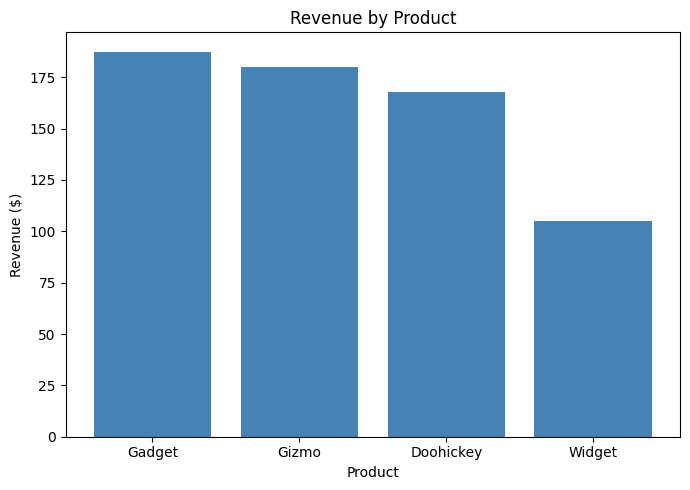

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(df['product'], df['revenue'], color='steelblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()